In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import plotly.express as px

In [102]:
iris = load_iris()

In [103]:
X = iris.data
y = iris.target
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [104]:
pca = PCA(n_components=2, random_state=32)
x_pca = pca.fit_transform(X)

In [105]:
df_plot = pd.DataFrame({"PC1": x_pca[:, 0], "PC2": x_pca[:, 1]})
px.scatter(df_plot, x="PC1", y="PC2", color=y.astype(str), title="PCA of Iris Dataset")

## K-MEANS

In [106]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=32, n_init="auto")
cluster = kmeans.fit_predict(X)

In [107]:
df_plot = pd.DataFrame({"PC1": x_pca[:, 0], "PC2": x_pca[:, 1], "Type": cluster})
px.scatter(df_plot, x="PC1", y="PC2", color="Type", title="KMeans Clustering of Iris Dataset")

In [108]:
kmeans.cluster_centers_

array([[6.85384615, 3.07692308, 5.71538462, 2.05384615],
       [5.006     , 3.428     , 1.462     , 0.246     ],
       [5.88360656, 2.74098361, 4.38852459, 1.43442623]])

In [109]:
kmeans.inertia_

78.85566582597728

In [110]:
df_plot = pd.DataFrame({"'sepal lenth (cm)'": X[:, 0], "'sepal width (cm)'": X[:, 1], "Type": cluster})
px.scatter(df_plot, x="'sepal lenth (cm)'", y="'sepal width (cm)'", color="Type", title="KMeans Clustering of Iris Dataset")

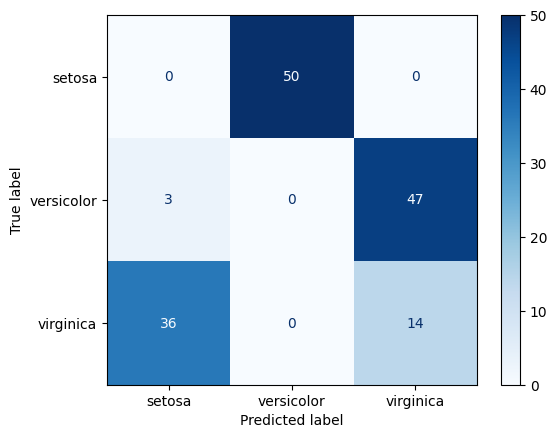

In [111]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
ConfusionMatrixDisplay.from_predictions(y, cluster, display_labels=iris.target_names, cmap=plt.cm.Blues)

In [112]:
cm = confusion_matrix(y, cluster)

In [113]:
from scipy.optimize import linear_sum_assignment

In [114]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [115]:

df_plot = pd.DataFrame({"PC1": x_pca[:, 0], "PC2": x_pca[:, 1], "Type": cluster, "Target": y.astype(str)})
px.scatter(df_plot, x="PC1", y="PC2", color="Type", symbol="Target", title="KMeans Clustering of Iris Dataset with True Labels")

In [116]:
df_plot = pd.DataFrame({"PC1": x_pca[:, 0], "PC2": x_pca[:, 1], "Type": iris.target_names[y]})
px.scatter(df_plot, x="PC1", y="PC2", color="Type", title="KMeans Clustering of Iris Dataset")


In [117]:
from sklearn.metrics import silhouette_score

sse = []
list_k = list(range(2, 20))  # on commence à 2, silhouette_score exige au moins 2 clusters
silhouette = []

for k in list_k:
    kmeans = KMeans(n_clusters=k, random_state=32, n_init="auto")
    cluster = kmeans.fit_predict(x_pca)
    silhouette.append(silhouette_score(x_pca, cluster))
    sse.append(kmeans.inertia_)

px.line(pd.DataFrame({"k": list_k, "SSE": sse}), x="k", y="SSE", title="Elbow Method for Optimal k")

In [118]:
px.line(pd.DataFrame({"k": list_k, "Silhouette Score": silhouette}), x="k", y="Silhouette Score", title="Silhouette Score for Optimal k")

## DBSCAN

In [119]:
from sklearn.cluster import DBSCAN

In [120]:
dbscan = DBSCAN(eps=0.6, min_samples=5)
cluster_dbscan = dbscan.fit_predict(x_pca)

In [121]:
np.unique(cluster_dbscan)

array([-1,  0,  1])

In [122]:
df_plot = pd.DataFrame({"PC1": x_pca[:, 0], "PC2": x_pca[:, 1], "Type": cluster_dbscan})
px.scatter(df_plot, x="PC1", y="PC2", color="Type", title="DBSCAN Clustering Results")